In [50]:
# Import necessary libraries
from pathlib import Path  # For handling file paths
import pandas as pd  # For data manipulation and analysis
from sklearn import preprocessing  # For data preprocessing
from sklearn.metrics import pairwise  # For computing pairwise distances
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster  # For hierarchical clustering
from sklearn.cluster import KMeans  # For K-means clustering
import matplotlib.pyplot as plt  # For creating visualizations
import seaborn as sns  # For enhanced visualizations
from pandas.plotting import parallel_coordinates  # For creating parallel coordinates plots
import dmba  # Data Mining for Business Analytics package

In [51]:
name ='Nneka Ekwemuka'

In [52]:
%matplotlib inline  
# Display plots inline in Jupyter notebook
from pathlib import Path

In [53]:
utilities_df = pd.read_csv('Utilities.csv')

In [54]:
utilities_df.head(5)

,Company,Fixed_charge,RoR,Cost,Load_factor,Demand_growth,Sales,Nuclear,Fuel_Cost
0,Arizona,1.06,9.2,151,54.4,1.6,9077,0.0,0.628
1,Boston,0.89,10.3,202,57.9,2.2,5088,25.3,1.555
2,Central,1.43,15.4,113,53.0,3.4,9212,0.0,1.058
3,Commonwealth,1.02,11.2,168,56.0,0.3,6423,34.3,0.700
4,NY,1.49,8.8,192,51.2,1.0,3300,15.6,2.044


In [55]:
# set row names to the utilities column
utilities_df.set_index('Company', inplace=True)

In [56]:
# compute Euclidean distance
d = pairwise.pairwise_distances(utilities_df,metric='euclidean')

In [57]:
pd.DataFrame(d, columns=utilities_df.index,index=utilities_df.index).head(5)

Company,Arizona,Boston,Central,Commonwealth,NY,Florida,Hawaiian,Idaho,Kentucky,Madison,...,Northern,Oklahoma,Pacific,Puget,San Diego,Southern,Texas,Wisconsin,United,Virginia
Company,,,,,,,,,,,,,,,,,,,,,
Arizona,0.000000,3989.408076,140.402855,2654.277632,5777.167672,2050.529440,1435.265019,4006.104187,671.276346,2622.699002,...,1899.279821,598.556633,2609.045363,6914.742065,3363.061626,1063.009074,4430.251585,1790.485648,2427.588875,1016.617691
Boston,3989.408076,0.000000,4125.044132,1335.466502,1788.068027,6039.689076,2554.287162,7994.155985,3318.276558,1367.090634,...,2091.160485,4586.302564,1380.749962,10903.146464,629.760748,5052.331669,8419.610541,2199.721665,1562.210811,5005.081262
Central,140.402855,4125.044132,0.000000,2789.759674,5912.552908,1915.155154,1571.295401,3872.257626,807.920792,2758.559663,...,2035.441520,461.341670,2744.502847,6780.430307,3498.113013,928.749249,4295.014690,1925.772564,2563.637362,883.535455
Commonwealth,2654.277632,1335.466502,2789.759674,0.000000,3123.153215,4704.363099,1219.560005,6659.534567,1983.314354,43.648894,...,756.831954,3250.984589,56.644626,9568.434429,710.292965,3717.202963,7084.372839,864.273153,232.476871,3670.018191
NY,5777.167672,1788.068027,5912.552908,3123.153215,0.000000,7827.429211,4342.093798,9782.158178,5106.094153,3155.095594,...,3879.167462,6373.743249,3168.177463,12691.155108,2414.698757,6840.150291,10207.392630,3987.335962,3350.073118,6793.035300


In [58]:
# using pandas*
utilities_df_norm = (utilities_df - utilities_df.mean())/utilities_df.std()

In [59]:
# compute normalized distance based on Sales and Fuel Cost
utilities_df_norm[['Sales', 'Fuel_Cost']]
d_norm = pairwise.pairwise_distances(utilities_df_norm[['Sales', 'Fuel_Cost']], metric='euclidean')

In [60]:
pd.DataFrame(d_norm, columns=utilities_df.index, index=utilities_df.index).head(5)

Company,Arizona,Boston,Central,Commonwealth,NY,Florida,Hawaiian,Idaho,Kentucky,Madison,...,Northern,Oklahoma,Pacific,Puget,San Diego,Southern,Texas,Wisconsin,United,Virginia
Company,,,,,,,,,,,,,,,,,,,,,
Arizona,0.000000,2.010329,0.774179,0.758738,3.021907,1.244422,1.885248,1.265638,0.461292,0.738650,...,0.564657,0.182648,1.570780,1.947668,2.509043,0.913621,1.247976,0.521491,2.761745,1.252350
Boston,2.010329,0.000000,1.465703,1.582821,1.013370,1.792397,0.740283,3.176654,1.557738,1.719632,...,1.940166,2.166078,0.478334,3.501390,0.679634,1.634425,2.890560,1.654255,1.100595,1.479261
Central,0.774179,1.465703,0.000000,1.015710,2.432528,0.631892,1.156092,1.732777,0.419254,1.102287,...,1.113433,0.855093,0.987772,2.065643,1.836762,0.276440,1.428159,0.838967,2.034824,0.510365
Commonwealth,0.758738,1.582821,1.015710,0.000000,2.571969,1.643857,1.746027,2.003230,0.629994,0.138758,...,0.377004,0.937389,1.258835,2.699060,2.202930,1.278514,1.998818,0.243408,2.547116,1.502093
NY,3.021907,1.013370,2.432528,2.571969,0.000000,2.635573,1.411695,4.162561,2.566439,2.705445,...,2.938637,3.174588,1.462019,4.397433,0.715629,2.558409,3.831132,2.661786,0.952507,2.328691


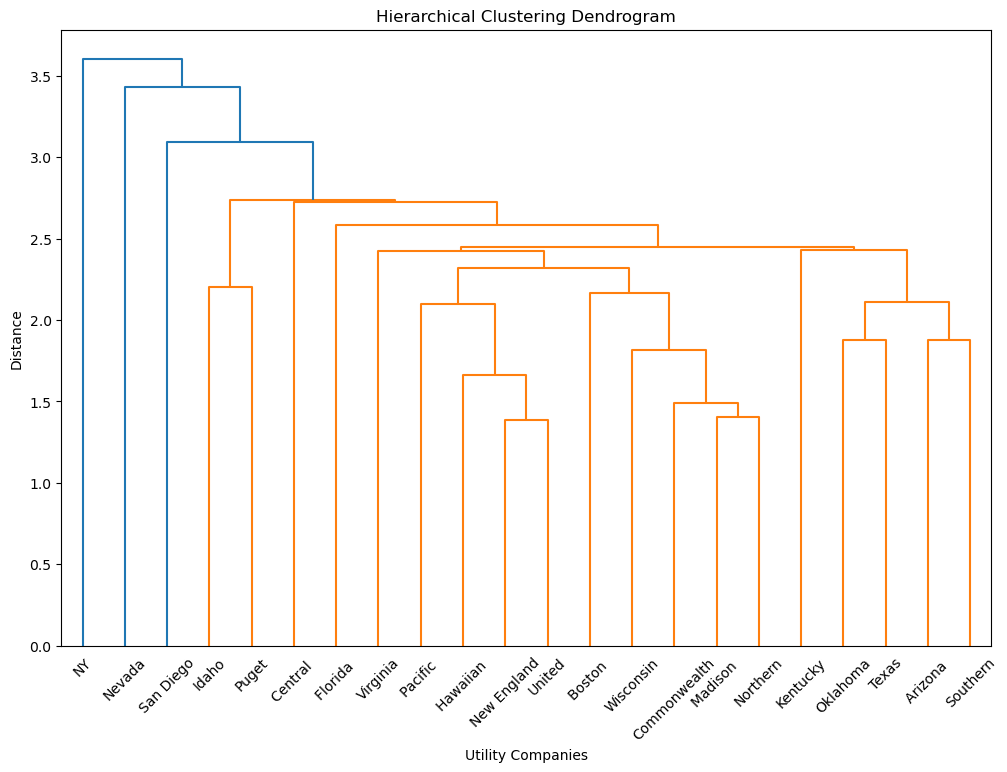

In [61]:
# Import necessary libraries
from pathlib import Path
import pandas as pd
from sklearn import preprocessing
from sklearn.metrics import pairwise
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import parallel_coordinates
import dmba

# Your clustering code
# (Assuming utilities_df_norm is your pre-processed DataFrame)
Z = linkage(utilities_df_norm, method='single')

# Create a figure for better sizing
plt.figure(figsize=(12, 8))

# Generate the dendrogram
dendrogram(Z, labels=utilities_df_norm.index, color_threshold=2.75)

# Add a title and labels for clarity
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Utility Companies')
plt.ylabel('Distance')

# This is the line you need to add to display the chart
plt.show()

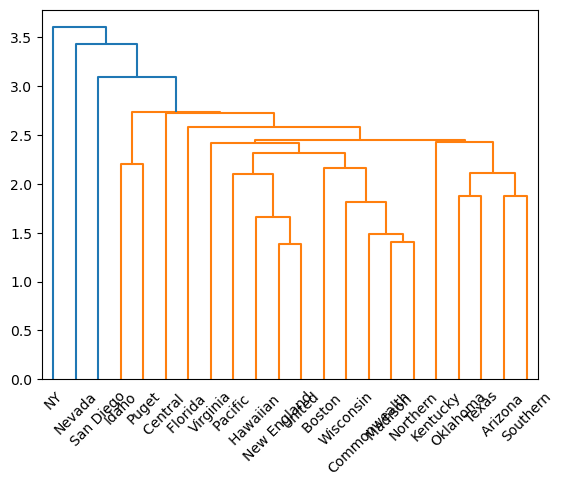

In [62]:
Z = linkage(utilities_df_norm, method='single')
dendrogram(Z, labels=utilities_df_norm.index,
color_threshold=2.75)
plt.show()

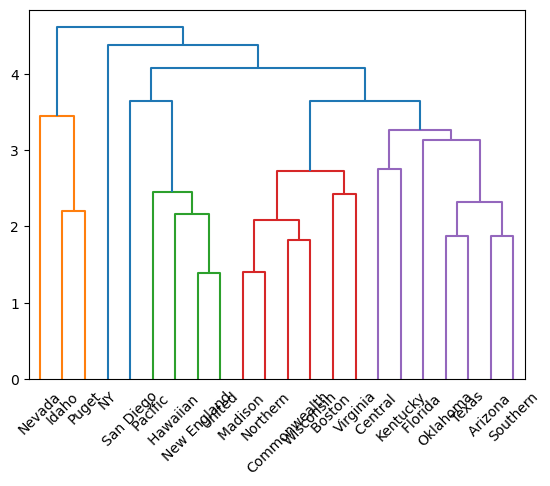

In [63]:
Z = linkage(utilities_df_norm, method='average')
dendrogram(Z, labels=utilities_df_norm.index,
color_threshold=3.6)
plt.show()

In [64]:
 memb = fcluster (linkage(utilities_df_norm, method='average'), 6, criterion = 'maxclust')

In [65]:
memb = pd.Series(memb, index=utilities_df_norm.index)
for key, item in memb.groupby(memb):
    print(key, ': ', ', '.join(item.index))  # Properly indented this line

1 :  Idaho, Nevada, Puget
2 :  Hawaiian , New England, Pacific , United
3 :  San Diego
4 :  Boston , Commonwealth, Madison , Northern, Wisconsin, Virginia
5 :  Arizona , Central , Florida , Kentucky, Oklahoma, Southern, Texas
6 :  NY


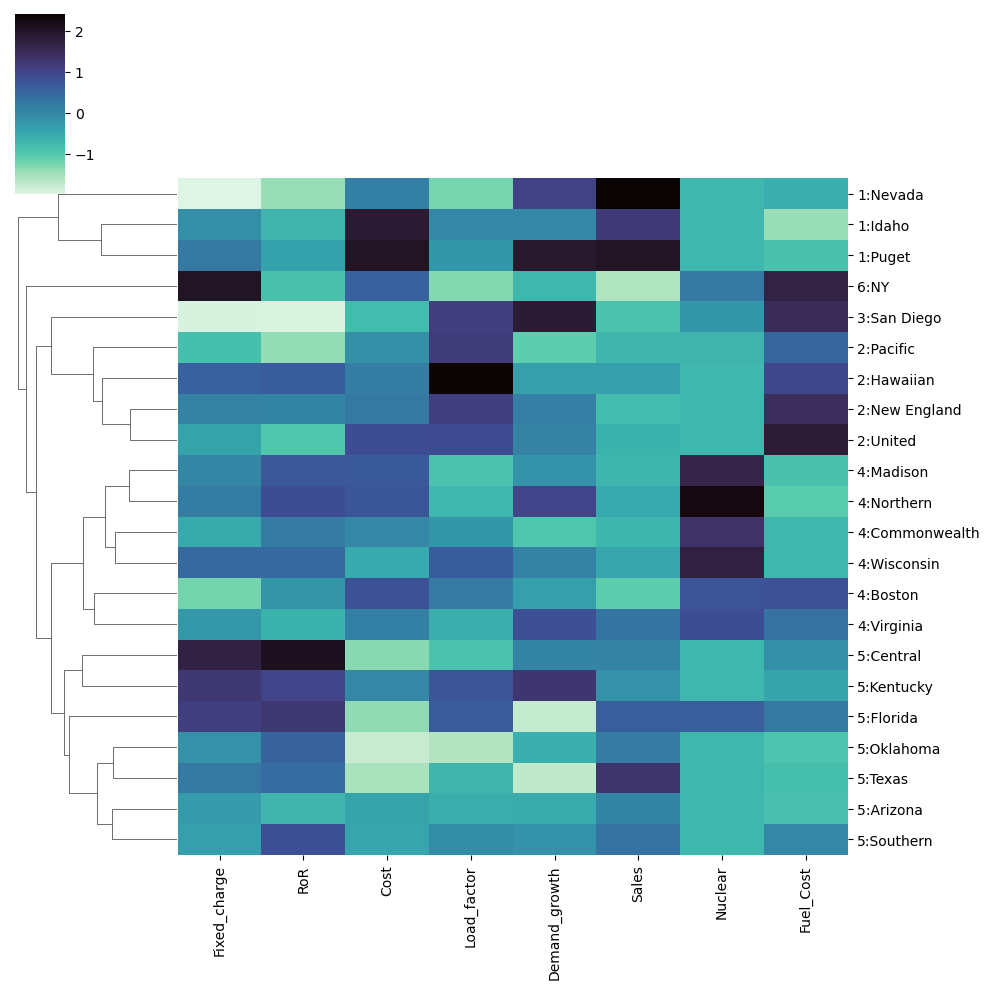

In [66]:
# Fix: Split the code into two separate lines
utilities_df_norm.index = ['{}:{}'. format(cluster, state) for cluster, state in zip(memb, utilities_df_norm.index)]
sns.clustermap(utilities_df_norm, method='average', col_cluster=False, cmap="mako_r")
plt.show()

In [67]:
# Load and preprocess data
utilities_df = pd.read_csv('Utilities.csv')
utilities_df.set_index('Company', inplace=True)
utilities_df = utilities_df.apply(lambda x:
x.astype('float64'))

In [68]:
# Normalize distances
utilities_df_norm = utilities_df.apply(preprocessing.scale, axis=0)


In [69]:
kmeans = KMeans(n_clusters=6, random_state=0).fit(utilities_df_norm)


In [70]:
# Cluster membership
memb = pd.Series(kmeans.labels_, index=utilities_df_norm.index)
for key, item in memb.groupby(memb):
    print(key, ': ', ', '.join(item.index))

0 :  Commonwealth, Madison , Northern, Wisconsin, Virginia
1 :  Pacific 
2 :  Arizona , Central , Florida , Oklahoma, Southern, Texas
3 :  Idaho, Nevada, Puget
4 :  Kentucky
5 :  Boston , NY, Hawaiian , New England, San Diego, United


In [71]:
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=utilities_df_norm.columns)

In [72]:
print(centroids)

   Fixed_charge       RoR      Cost  Load_factor  Demand_growth     Sales  \
0     -0.011599  0.339180  0.224086    -0.366466       0.170386 -0.411331   
1     -0.854783 -1.430526 -0.103911     1.198264      -1.096618 -0.705245   
2      0.393352  0.758801 -1.176527    -0.533952      -0.801203  0.444577   
3     -0.614402 -0.852787  1.370418    -0.491890       1.015056  1.900210   
4      1.253178  1.032466 -0.004518     0.785285       1.299530 -0.146480   
5     -0.142884 -0.548714  0.322651     0.754694       0.117868 -0.909952   

    Nuclear  Fuel_Cost  
0  1.601868  -0.609460  
1 -0.676588   0.547149  
2 -0.502869  -0.416385  
3 -0.731447  -0.988493  
4 -0.731447  -0.443073  
5 -0.231625   1.401169  


In [73]:
# distances of each record to the cluster centers
distances = kmeans.transform(utilities_df_norm)

In [74]:
# find closest cluster for each record
minSquaredDistances = distances.min(axis=1) ** 2

In [75]:
# combine with cluster labels into a data frame
df = pd.DataFrame({'squaredDistance': minSquaredDistances,
'cluster': kmeans.labels_}, index=utilities_df_norm.index)

In [76]:
# group by cluster and print information
for cluster, data in df.groupby('cluster'):
    count = len(data)
    withinClustSS = data.squaredDistance.sum()
    print(f'Cluster {cluster} ({count} members): {withinClustSS:.2f} within cluster')

Cluster 0 (5 members): 10.66 within cluster
Cluster 1 (1 members): 0.00 within cluster
Cluster 2 (6 members): 20.28 within cluster
Cluster 3 (3 members): 9.99 within cluster
Cluster 4 (1 members): 0.00 within cluster
Cluster 5 (6 members): 32.27 within cluster


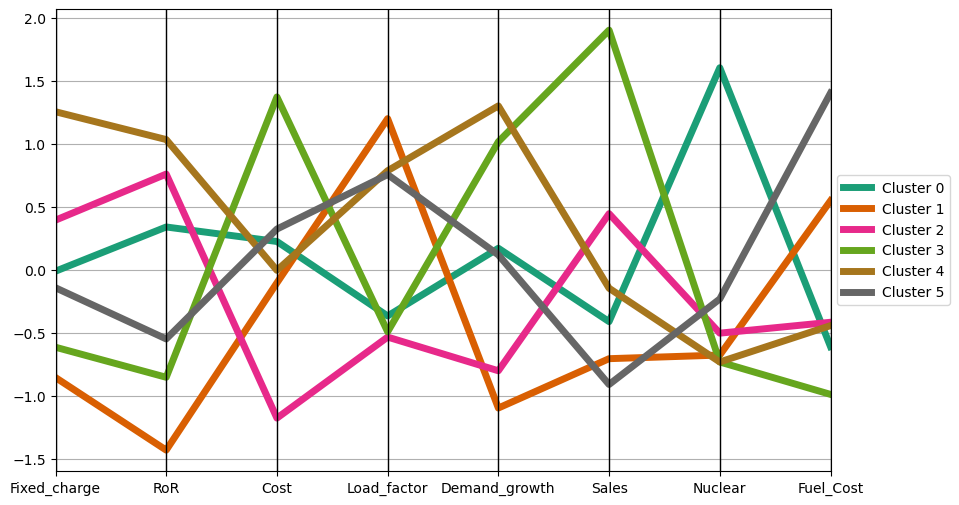

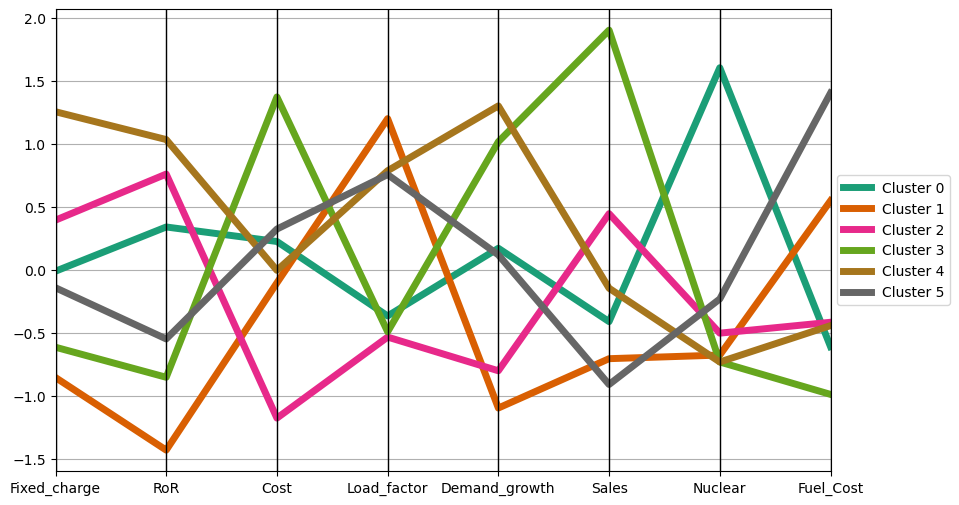

In [78]:
centroids['cluster'] = ['Cluster {}'.format(i) for i in
centroids.index]
plt.figure(figsize=(10,6))
parallel_coordinates(centroids, class_column='cluster',
colormap='Dark2', linewidth=5)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()